In [1]:
import sqlite3
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

conn = sqlite3.connect("../retailiq.db")
df = pd.read_sql("SELECT * FROM customer_features", conn)
conn.close()

feature_cols = [
    "recency_days", "frequency", "repeat_order_count",
    "avg_days_between_orders", "avg_review_score", "review_count",
    "avg_delivery_days", "avg_delay_days"
]
target = "monetary"

model_df = df[feature_cols + [target]].dropna()
X = model_df[feature_cols]

model = joblib.load("../models_clv.pkl")
print("Model loaded:", type(model))

c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [2]:
# Use a sample for speed if X is large (SHAP on the full RF can be slow)
X_sample = X.sample(min(2000, len(X)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2000, 8)


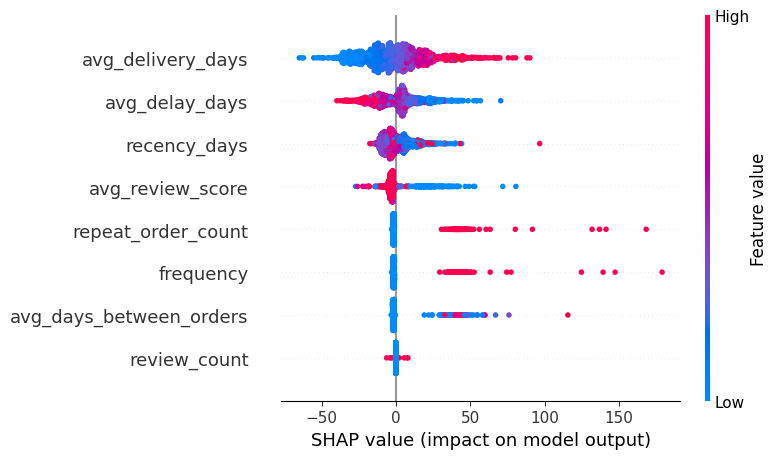

In [3]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("../docs/shap_clv_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Find one high and one low prediction
preds = model.predict(X)
X_with_preds = X.copy()
X_with_preds["predicted_clv"] = preds

high_idx = X_with_preds["predicted_clv"].idxmax()
low_idx = X_with_preds["predicted_clv"].idxmin()

print("High-value customer prediction:", X_with_preds.loc[high_idx, "predicted_clv"])
print("Low-value customer prediction:", X_with_preds.loc[low_idx, "predicted_clv"])

# Explain the high-value customer
sample_idx_in_shap = X_sample.index.get_indexer([high_idx])[0] if high_idx in X_sample.index else None
if sample_idx_in_shap is not None and sample_idx_in_shap >= 0:
    shap.force_plot(
        explainer.expected_value, shap_values[sample_idx_in_shap],
        X_sample.iloc[sample_idx_in_shap], matplotlib=True, show=False
    )
    plt.savefig("../docs/shap_clv_high_value_example.png", dpi=150, bbox_inches="tight")
    plt.show()

High-value customer prediction: 917.1595172648799
Low-value customer prediction: 102.81065998236105
